In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all charts
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Make charts bigger and clearer
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load clean dataset
df = pd.read_csv(r'C:\Users\User\Desktop\DataAnalysesProject\data\clean\online_retail_final.csv')

# Fix datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Data loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Data loaded!
Shape: (396473, 18)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalRevenue', 'Month', 'Year', 'DayOfWeek', 'Quantity_clipped', 'LogRevenue', 'MonthName', 'MonthYear', 'IsWeekend', 'Hour']


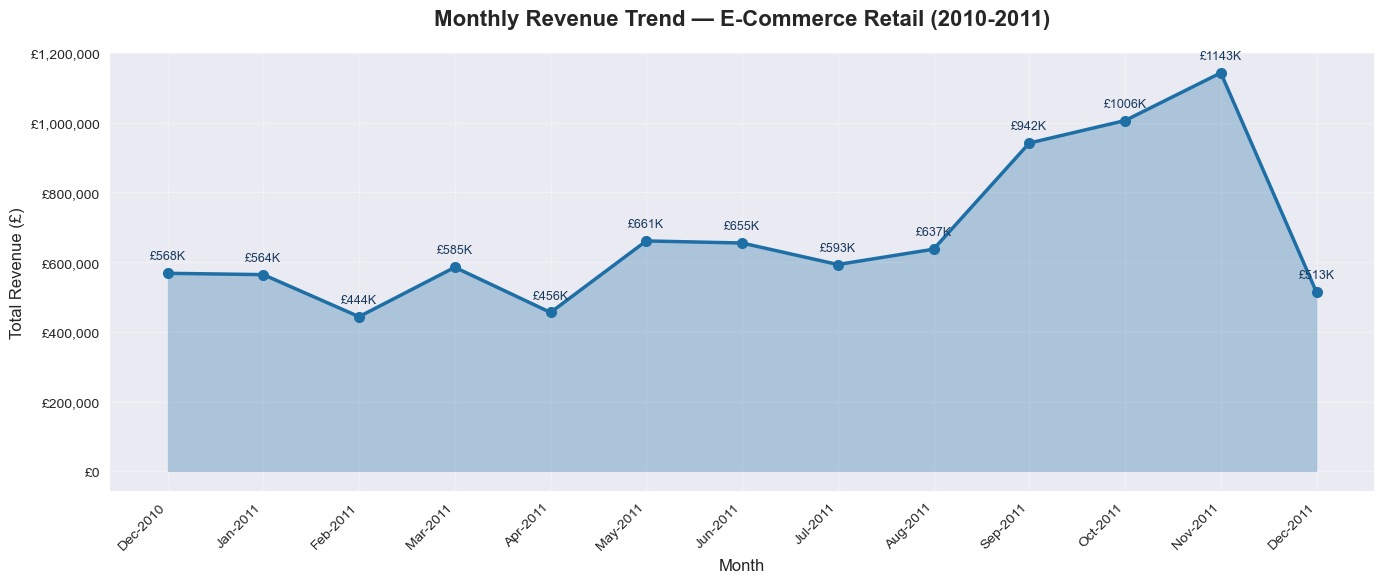

✅ Chart 1 saved!


In [3]:
# Calculate monthly revenue
monthly_revenue = df.groupby(['Year', 'Month', 'MonthName', 'MonthYear'])['TotalRevenue'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values(['Year', 'Month'])

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot line chart
ax.plot(monthly_revenue['MonthYear'], 
        monthly_revenue['TotalRevenue'], 
        color='#1E6FA5', linewidth=2.5, marker='o', markersize=8)

# Fill area under line
ax.fill_between(monthly_revenue['MonthYear'], 
                monthly_revenue['TotalRevenue'], 
                alpha=0.3, color='#1E6FA5')

# Add value labels on each point
for i, row in monthly_revenue.iterrows():
    ax.annotate(f"£{row['TotalRevenue']/1000:.0f}K", 
                xy=(row['MonthYear'], row['TotalRevenue']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='#1A3A5C')

# Formatting
ax.set_title('Monthly Revenue Trend — E-Commerce Retail (2010-2011)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Revenue (£)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig(r'C:\Users\User\Desktop\DataAnalysesProject\visuals\01_monthly_revenue_trend.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

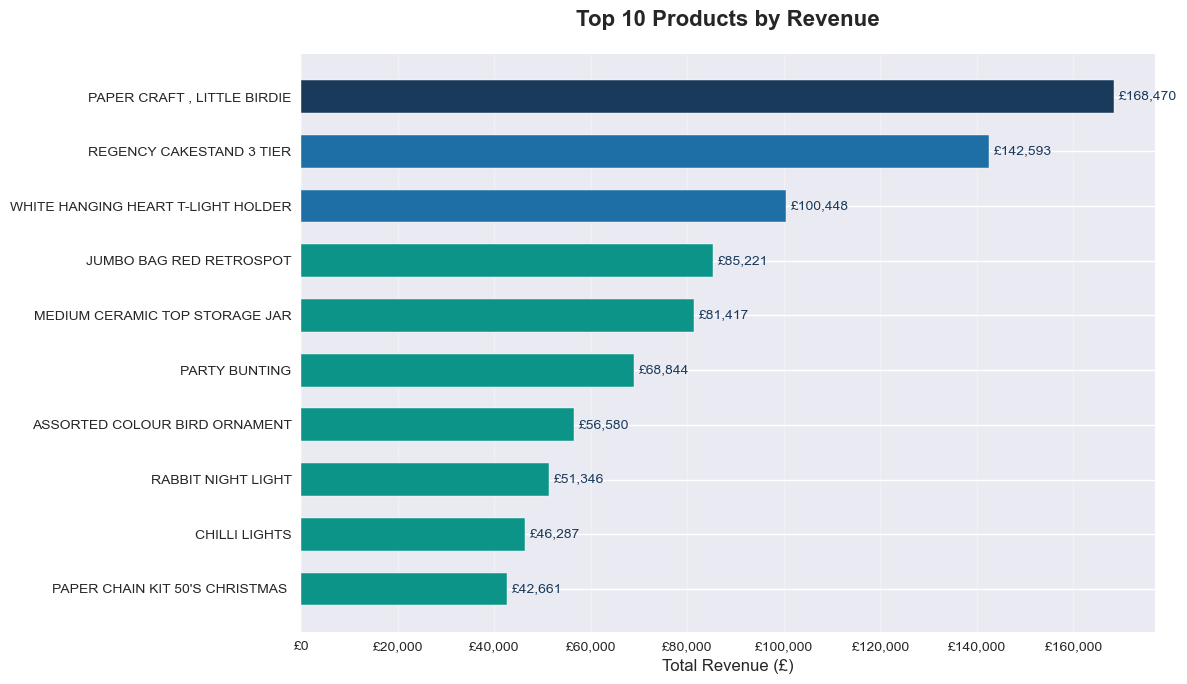

✅ Chart 2 saved!


In [4]:
# Calculate top 10 products
top_products = df.groupby('Description')['TotalRevenue'].sum()\
                 .sort_values(ascending=False).head(10).reset_index()

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot horizontal bar chart
colors = ['#1A3A5C' if i == 0 else '#1E6FA5' if i < 3 else '#0D9488' 
          for i in range(len(top_products))]

bars = ax.barh(top_products['Description'], 
               top_products['TotalRevenue'],
               color=colors, edgecolor='white', height=0.6)

# Add value labels on bars
for bar, val in zip(bars, top_products['TotalRevenue']):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=10, color='#1A3A5C')

# Formatting
ax.set_title('Top 10 Products by Revenue', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (£)', fontsize=12)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
ax.grid(True, axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save chart
plt.savefig(r'C:\Users\User\Desktop\DataAnalysesProject\visuals\02_top_products.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

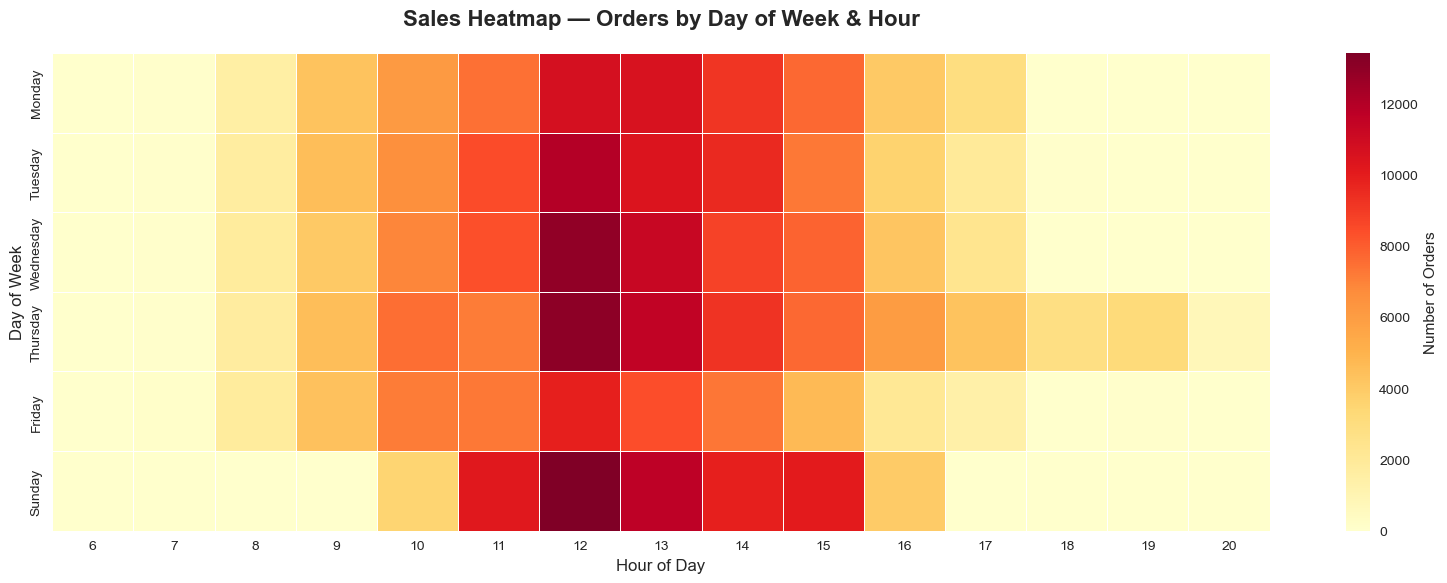

✅ Chart 3 saved!


In [6]:
# Create pivot table - Days vs Hours
heatmap_data = df.groupby(['DayOfWeek', 'Hour'])['InvoiceNo'].count().reset_index()
heatmap_pivot = heatmap_data.pivot_table(
    index='DayOfWeek', 
    columns='Hour', 
    values='InvoiceNo', 
    fill_value=0
)

# Auto rename rows based on actual days in data
all_day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pivot.index = [all_day_names[i] for i in heatmap_pivot.index]

# Create figure
fig, ax = plt.subplots(figsize=(16, 6))

# Plot heatmap
sns.heatmap(heatmap_pivot, 
            cmap='YlOrRd',
            annot=False,
            fmt='d',
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Number of Orders'})

# Formatting
ax.set_title('Sales Heatmap — Orders by Day of Week & Hour', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)

plt.tight_layout()

# Save
plt.savefig(r'C:\Users\User\Desktop\DataAnalysesProject\visuals\03_sales_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

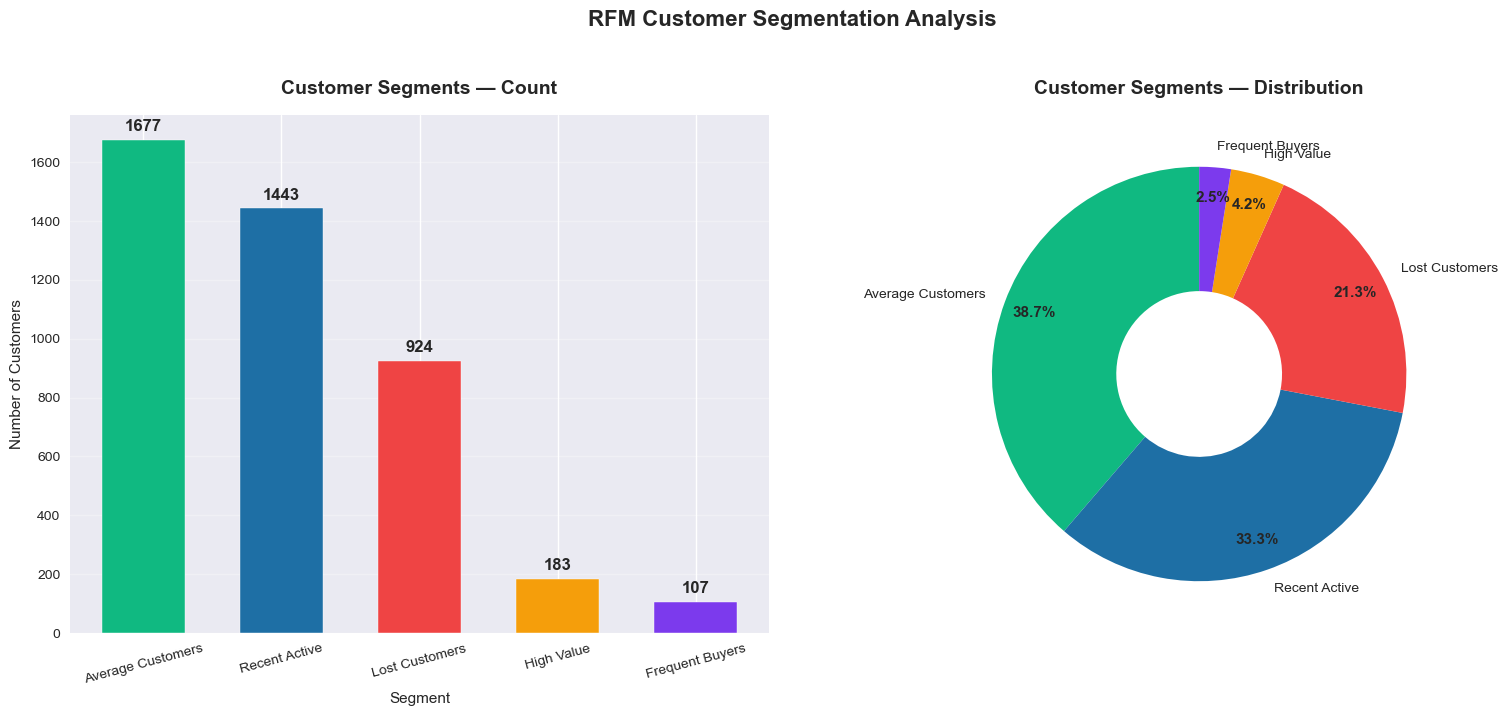

✅ Chart 4 saved!


In [7]:
# Load RFM data
rfm = pd.read_csv(r'C:\Users\User\Desktop\DataAnalysesProject\data\clean\rfm_segments.csv')

# Count customers per segment
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

# Colors for segments
colors = ['#10B981', '#1E6FA5', '#EF4444', '#F59E0B', '#7C3AED']

# Create figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1 - Bar chart
bars = ax1.bar(segment_counts['Segment'], 
               segment_counts['Count'],
               color=colors, edgecolor='white', width=0.6)

# Add value labels on bars
for bar, val in zip(bars, segment_counts['Count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_title('Customer Segments — Count', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Segment', fontsize=11)
ax1.set_ylabel('Number of Customers', fontsize=11)
ax1.tick_params(axis='x', rotation=15)
ax1.grid(True, axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Chart 2 - Pie chart
wedges, texts, autotexts = ax2.pie(
    segment_counts['Count'],
    labels=segment_counts['Segment'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.6)
)

# Style pie chart text
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax2.set_title('Customer Segments — Distribution', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('RFM Customer Segmentation Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save
plt.savefig(r'C:\Users\User\Desktop\DataAnalysesProject\visuals\04_rfm_segments.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

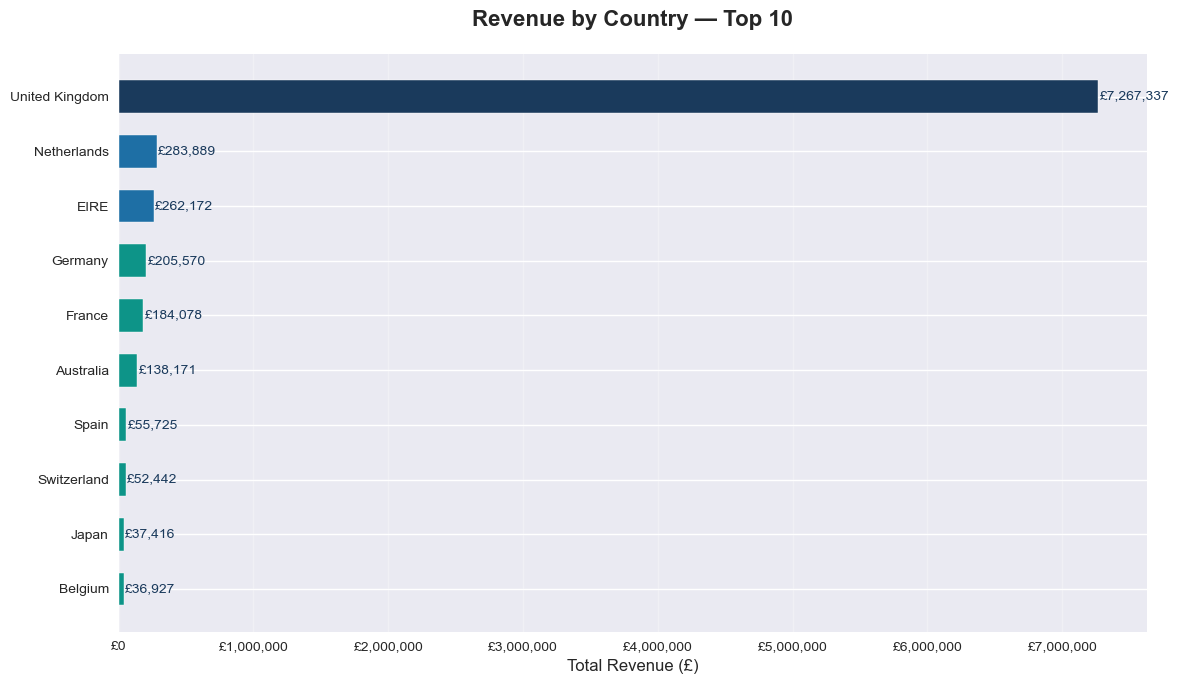

✅ Chart 5 saved!


In [8]:
# Top 10 countries by revenue
country_revenue = df.groupby('Country')['TotalRevenue'].sum()\
                    .sort_values(ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#1A3A5C' if i == 0 else '#1E6FA5' if i < 3 else '#0D9488' 
          for i in range(len(country_revenue))]

bars = ax.barh(country_revenue['Country'],
               country_revenue['TotalRevenue'],
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, country_revenue['TotalRevenue']):
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=10, color='#1A3A5C')

ax.set_title('Revenue by Country — Top 10', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (£)', fontsize=12)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
ax.grid(True, axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\DataAnalysesProject\visuals\05_revenue_by_country.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

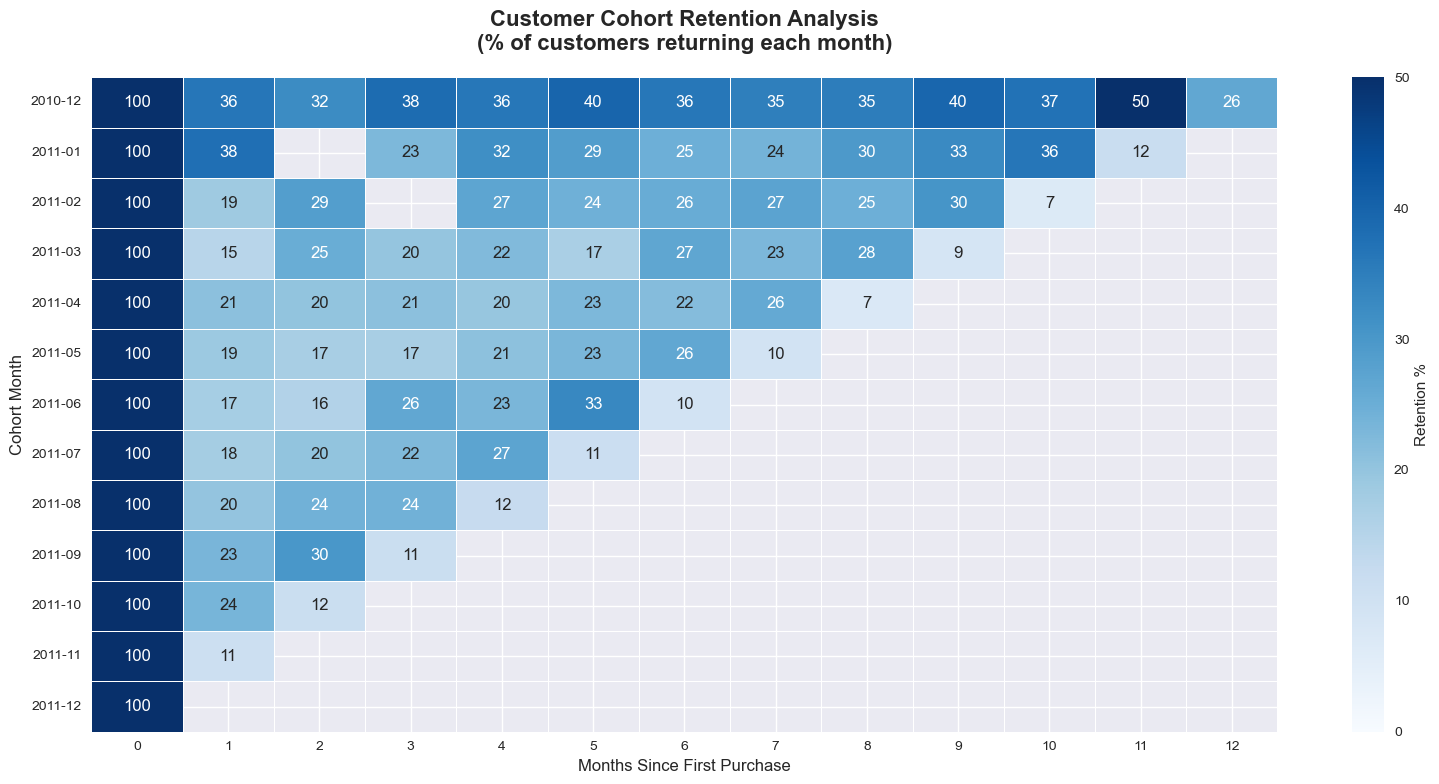

✅ Chart 6 saved!


In [9]:
# Step 1 — Find each customer's first purchase month
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')

first_purchase = df.groupby('CustomerID')['OrderMonth'].min().reset_index()
first_purchase.columns = ['CustomerID', 'CohortMonth']

# Step 2 — Merge first purchase back to main dataframe
df_cohort = df.merge(first_purchase, on='CustomerID')

# Step 3 — Calculate months since first purchase
df_cohort['OrderMonth'] = df_cohort['InvoiceDate'].dt.to_period('M')
df_cohort['CohortIndex'] = (
    df_cohort['OrderMonth'].dt.to_timestamp() - 
    df_cohort['CohortMonth'].dt.to_timestamp()
).dt.days // 30

# Step 4 — Count unique customers per cohort per month
cohort_data = df_cohort.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# Step 5 — Calculate retention percentage
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

# Step 6 — Plot heatmap
fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(retention,
            annot=True,
            fmt='.0f',
            cmap='Blues',
            vmin=0, vmax=50,
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Retention %'})

ax.set_title('Customer Cohort Retention Analysis\n(% of customers returning each month)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Cohort Month', fontsize=12)

plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\DataAnalysesProject\visuals\06_cohort_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

## Day 11 - EDA Summary

### Charts Created:
1. Monthly Revenue Trend (line chart)
2. Top 10 Products Bar Chart
3. Sales Heatmap (Day vs Hour)
4. RFM Segment Distribution (bar + donut)
5. Revenue by Country
6. Cohort Retention Analysis

### Key Visual Findings:
- November 2011 = peak revenue month (£1.14M)
- Wednesday 12pm = busiest ordering time
- Dec 2010 cohort = best retention (50% after 11 months)
- UK dominates with £7.2M (96% of revenue)
- Average Customers = largest segment (38.7%)

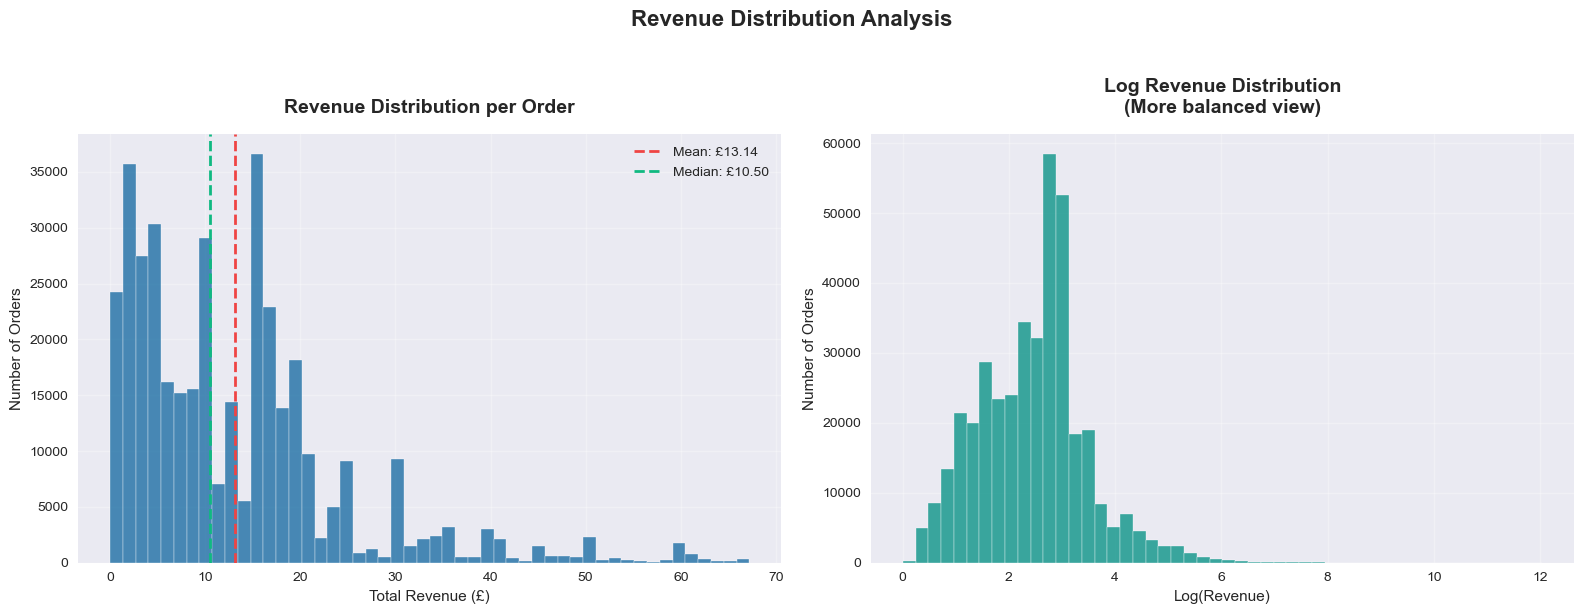

✅ Chart 7 saved!


In [10]:
# Remove extreme outliers for better visualization
df_viz = df[df['TotalRevenue'] < df['TotalRevenue'].quantile(0.95)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 - Revenue Distribution Histogram
ax1.hist(df_viz['TotalRevenue'], 
         bins=50, 
         color='#1E6FA5', 
         edgecolor='white',
         alpha=0.8)

# Add mean and median lines
mean_val = df_viz['TotalRevenue'].mean()
median_val = df_viz['TotalRevenue'].median()

ax1.axvline(mean_val, color='#EF4444', linewidth=2, 
            linestyle='--', label=f'Mean: £{mean_val:.2f}')
ax1.axvline(median_val, color='#10B981', linewidth=2, 
            linestyle='--', label=f'Median: £{median_val:.2f}')

ax1.set_title('Revenue Distribution per Order', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Total Revenue (£)', fontsize=11)
ax1.set_ylabel('Number of Orders', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Chart 2 - Log Revenue Distribution
ax2.hist(df['LogRevenue'], 
         bins=50, 
         color='#0D9488', 
         edgecolor='white',
         alpha=0.8)

ax2.set_title('Log Revenue Distribution\n(More balanced view)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Log(Revenue)', fontsize=11)
ax2.set_ylabel('Number of Orders', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Revenue Distribution Analysis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig(r'C:\Users\User\Desktop\DataAnalysesProject\visuals\07_revenue_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved!")

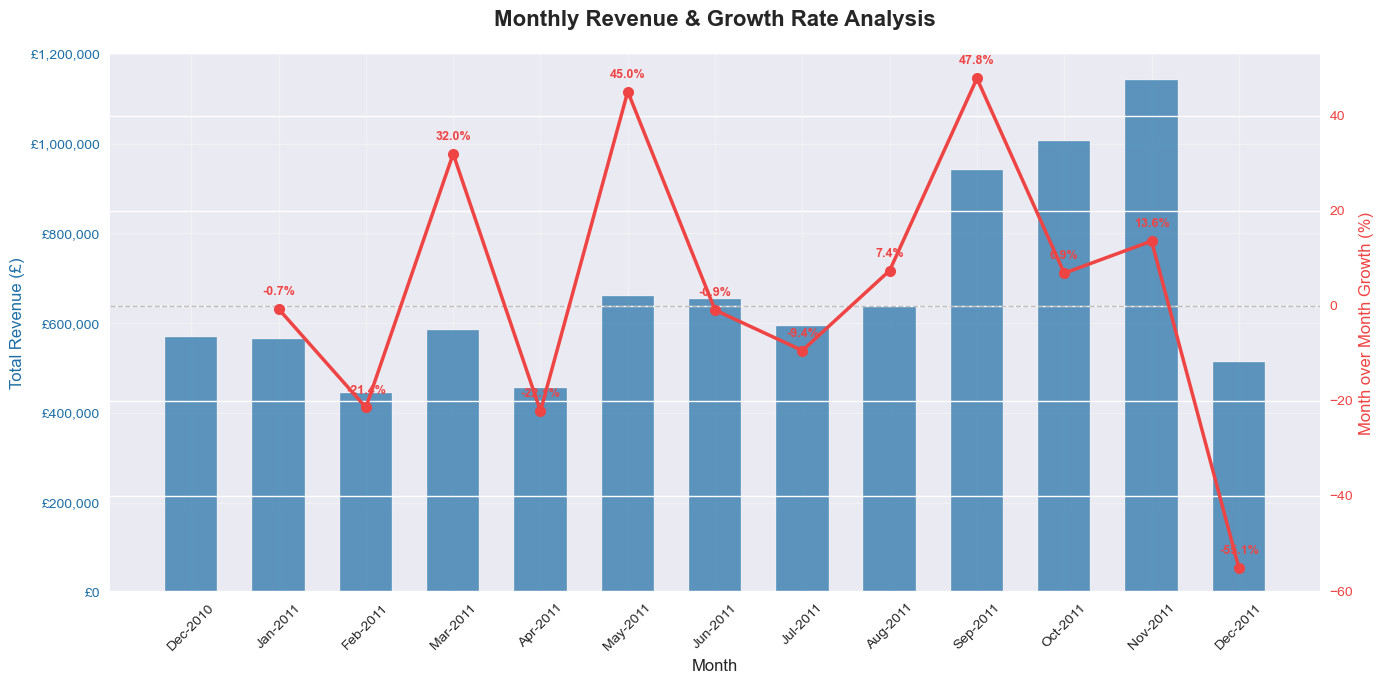

✅ Chart 8 saved!


In [11]:
# Calculate monthly revenue and growth
monthly = df.groupby(['Year', 'Month', 'MonthName', 'MonthYear'])['TotalRevenue']\
            .sum().reset_index().sort_values(['Year', 'Month'])

# Calculate growth percentage
monthly['GrowthPct'] = monthly['TotalRevenue'].pct_change() * 100

# Create figure with dual axis
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart — Monthly Revenue (left axis)
colors = ['#10B981' if x >= 0 else '#EF4444' 
          for x in monthly['GrowthPct'].fillna(0)]
bars = ax1.bar(monthly['MonthYear'], 
               monthly['TotalRevenue'],
               color='#1E6FA5', alpha=0.7, 
               edgecolor='white', width=0.6)

ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Revenue (£)', fontsize=12, color='#1E6FA5')
ax1.tick_params(axis='y', labelcolor='#1E6FA5')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))

# Line chart — Growth % (right axis)
ax2 = ax1.twinx()
ax2.plot(monthly['MonthYear'], monthly['GrowthPct'],
         color='#EF4444', linewidth=2.5, 
         marker='o', markersize=8, zorder=5)

# Add growth labels
for i, (x, y) in enumerate(zip(monthly['MonthYear'], monthly['GrowthPct'])):
    if pd.notna(y):
        ax2.annotate(f'{y:.1f}%',
                    xy=(x, y), xytext=(0, 10),
                    textcoords='offset points',
                    ha='center', fontsize=9,
                    color='#EF4444', fontweight='bold')

# Add zero line
ax2.axhline(y=0, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax2.set_ylabel('Month over Month Growth (%)', fontsize=12, color='#EF4444')
ax2.tick_params(axis='y', labelcolor='#EF4444')

# Title
plt.title('Monthly Revenue & Growth Rate Analysis',
          fontsize=16, fontweight='bold', pad=20)

ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\DataAnalysesProject\visuals\08_monthly_growth.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved!")

## EDA Phase Complete! ✅

### 8 Charts Created and Saved:
1. Monthly Revenue Trend
2. Top 10 Products by Revenue
3. Sales Heatmap (Day vs Hour)
4. RFM Customer Segments
5. Revenue by Country
6. Cohort Retention Analysis
7. Revenue Distribution
8. Monthly Growth Rate

### All charts saved to:
DataAnalysesProject/visuals/